Exported: fex_problem.svg, fex_problem.png


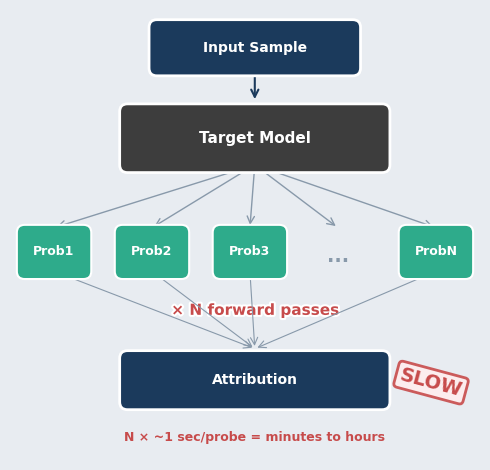

In [ ]:
"""
FEX Problem Visual — Compact square version v2
Tighter boxes, contrasting borders, closer bottom text
"""

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patheffects as pe
import os

saving_path = os.path.join(os.getcwd(), "saved")

# COLOR PALETTE
BG_COLOR = '#E8ECF1'
NAVY     = '#1B3A5C'
TEAL     = '#2EAB8B'
GOLD     = '#D4A843'
RED      = '#C74B4B'
WHITE    = '#FFFFFF'
GRAY     = '#8899AA'
LIGHT_BG = '#E8ECF1'

fig, ax = plt.subplots(1, 1, figsize=(5, 4.8))
fig.patch.set_facecolor(LIGHT_BG)
ax.set_facecolor(LIGHT_BG)
ax.set_xlim(0.5, 5.3)
ax.set_ylim(1.15, 5.8)
ax.axis('off')

def draw_box(x, y, w, h, label, facecolor, bordercolor, fontsize=10,
             fontcolor='white', borderwidth=2.0):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08",
                          facecolor=facecolor, edgecolor=bordercolor,
                          linewidth=borderwidth, zorder=5)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color=fontcolor, zorder=6)

def draw_arrow(x1, y1, x2, y2, color=GRAY, lw=1.5):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                             arrowstyle='->', mutation_scale=13,
                             color=color, linewidth=lw, zorder=4)
    ax.add_patch(arrow)

# INPUT — tight
draw_box(2.0, 5.2, 2.0, 0.42, 'Input Sample', NAVY, WHITE, fontsize=10)
draw_arrow(3.0, 5.2, 3.0, 4.85, NAVY)

# MODEL — tight
draw_box(1.7, 4.2, 2.6, 0.55, 'Target Model', '#3D3D3D', WHITE, fontsize=11, borderwidth=2.0)

# N PROBES — smaller boxes
probe_x = [0.65, 1.65, 2.65, 3.55, 4.55]
probe_labels = ['Probe1', 'Probe2', 'Probe3', '...', 'ProbeN']

for px, label in zip(probe_x, probe_labels):
    draw_arrow(3.0, 4.2, px + 0.3, 3.55, GRAY, lw=1.0)
    if label == '...':
        ax.text(px + 0.3, 3.25, '...', ha='center', va='center',
                fontsize=14, fontweight='bold', color=GRAY)
    else:
        draw_box(px, 3.1, 0.6, 0.4, label, TEAL, WHITE, fontsize=9, borderwidth=1.5)

# x N label
ax.text(3.0, 2.65, '× N Probes', ha='center', fontsize=11,
        fontweight='bold', color=RED,
        path_effects=[pe.withStroke(linewidth=3, foreground=WHITE)])

# Converge arrows
for px in [0.65, 1.65, 2.65, 4.55]:
    draw_arrow(px + 0.3, 3.1, 3.0, 2.3, GRAY, lw=0.8)

# ATTRIBUTION — tight
draw_box(1.7, 1.75, 2.6, 0.45, 'Attribution', NAVY, WHITE, fontsize=10, borderwidth=2.0)

# SLOW stamp
ax.text(4.8, 1.95, 'SLOW', ha='center', va='center', fontsize=14,
        fontweight='bold', color=RED, rotation=-15,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#FFEEEE',
                  edgecolor=RED, linewidth=2, alpha=0.9),
        zorder=10)

# Bottom cost line — closer to attribution
ax.text(3.0, 1.35, 'N × ~1 sec/probe = minutes to hours',
        ha='center', fontsize=9, color=RED, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(saving_path, 'fex_problem.svg'), format='svg',
            bbox_inches='tight', facecolor=LIGHT_BG)
plt.savefig(os.path.join(saving_path, 'fex_problem.png'), dpi=300,
            bbox_inches='tight', facecolor=LIGHT_BG)
print("Exported: fex_problem.svg, fex_problem.png")